# Step 11: Deploy ANN–LSTM Forecaster (60-day)

## What this notebook does

Uses your **winning model** from the lookback ablation:

> **ANN–LSTM with 60 days of SST + DHW history**

Given a reef location and an “as-of” date, it:

1. Loads the last **60 days** of SST & DHW  
2. Predicts SST & DHW at **+1, +3, +7** days  
3. Scores **bleaching risk** (DHW-aware)  
4. Compares to **persistence** (“tomorrow = today”) for sanity  

**Roles in the system**

| Job | Model |
|-----|--------|
| Maps / spatial twin | PINN (`pinn_model_best.h5`) |
| Short-term forecast | **This ANN–LSTM** |

> Standalone deploy notebook — does not modify notebooks 01–10.

## Import libraries

In [1]:
import os
import warnings
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")

from prepare_data import load_all_locations, apply_scalers, fit_scalers, LOCATIONS
from utils import calculate_bleaching_risk, calculate_location_baseline

print("TensorFlow", tf.__version__)
print("Locations:", LOCATIONS)

TensorFlow 2.20.0
Locations: ['hikkaduwa', 'kalpitiya', 'passikudha', 'south_east', 'trinco']


## Settings

In [2]:
LOOKBACK = 60
HORIZONS = [1, 3, 7]

# Prefer ablation winner; fall back to notebook-09 model
CANDIDATES = [
    Path("lstm_lookback_ablation") / "ann_lstm_L60_best.h5",
    Path("lstm_lookback_ablation") / "ann_lstm_L60_final.h5",
    Path("lstm_experiment") / "ann_lstm_best.h5",
    Path("lstm_experiment") / "ann_lstm_final.h5",
]

MODEL_PATH = next((p for p in CANDIDATES if p.exists()), None)
if MODEL_PATH is None:
    raise FileNotFoundError(
        "No ANN–LSTM model found. Run 09_lstm_sequence_forecast.ipynb "
        "or 10_lookback_ablation.ipynb first."
    )

OUT_DIR = Path("lstm_deploy")
OUT_DIR.mkdir(exist_ok=True)

print("Using model:", MODEL_PATH.resolve())
print("LOOKBACK =", LOOKBACK, " HORIZONS =", HORIZONS)

Using model: D:\corals\model\lstm_lookback_ablation\ann_lstm_L60_best.h5
LOOKBACK = 60  HORIZONS = [1, 3, 7]


## Load data, scalers, model

Scalers are rebuilt the same way as in training notebooks (`fit_scalers` on full multi-site data) so denormalisation matches.

In [3]:
df = load_all_locations()
scalers = fit_scalers(df)
df = apply_scalers(df, scalers)
df = df.sort_values(["location", "time"]).reset_index(drop=True)

model = keras.models.load_model(MODEL_PATH, compile=False)
print("Data rows:", len(df))
print("Date range:", df["time"].min(), "→", df["time"].max())
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

# Monthly baselines for risk
baselines = {}
for loc in LOCATIONS:
    path = os.path.join("sliot_dataset", loc, "sst_full.csv")
    if os.path.exists(path):
        baselines[loc] = calculate_location_baseline(path)
print("Baselines loaded for:", list(baselines.keys()))

Data rows: 20095
Date range: 2015-03-01 12:00:00+00:00 → 2026-03-01 12:00:00+00:00
Model input shape: (None, 60, 2)
Model output shape: (None, 6)
Baselines loaded for: ['hikkaduwa', 'kalpitiya', 'passikudha', 'south_east', 'trinco']


## Helper functions

In [4]:
def _inv(scaler, vals):
    vals = np.asarray(vals, dtype=float).reshape(-1, 1)
    fn = getattr(scaler, "feature_names_in_", None)
    if fn is not None and len(fn):
        return scaler.inverse_transform(pd.DataFrame(vals, columns=fn)).ravel()
    return scaler.inverse_transform(vals).ravel()


def get_history_window(location, as_of=None, lookback=LOOKBACK):
    """
    Return the last `lookback` daily rows for a location at/before as_of.
    as_of=None → use the latest available date for that site.
    """
    g = df[df["location"] == location].sort_values("time")
    if g.empty:
        raise ValueError(f"Unknown location: {location}. Choose from {LOCATIONS}")

    if as_of is not None:
        as_of = pd.Timestamp(as_of)
        if as_of.tzinfo is None:
            as_of = as_of.tz_localize("UTC")
        else:
            as_of = as_of.tz_convert("UTC")
        g = g[g["time"] <= as_of]

    if len(g) < lookback:
        raise ValueError(
            f"Need {lookback} days of history for {location}, found {len(g)}."
        )

    window = g.iloc[-lookback:].copy()
    return window


def forecast_ann_lstm(location, as_of=None):
    """
    Run 60-day ANN–LSTM forecast.

    Returns a DataFrame with columns:
      horizon_days, target_date, sst_pred, dhw_pred,
      sst_persist, risk_score, risk_level, anomaly, ...
    """
    window = get_history_window(location, as_of=as_of, lookback=LOOKBACK)
    issue_row = window.iloc[-1]
    issue_time = issue_row["time"]
    sst_issue = float(issue_row["analysed_sst"])
    dhw_issue = float(issue_row["degree_heating_week"])

    X = np.stack(
        [window["temp_norm"].values, window["dhw_norm"].values],
        axis=-1,
    ).astype(np.float32)[None, ...]  # (1, 60, 2)

    pred_n = np.asarray(model.predict(X, verbose=0)).reshape(1, -1)
    month = int(pd.Timestamp(issue_time).month)
    baseline = baselines.get(location, {}).get(month, 28.0)

    rows = []
    for k, h in enumerate(HORIZONS):
        sst = float(_inv(scalers["scaler_temp"], pred_n[:, 2 * k])[0])
        dhw = float(_inv(scalers["scaler_dhw"], pred_n[:, 2 * k + 1])[0])
        dhw = max(0.0, dhw)

        risk = calculate_bleaching_risk(
            current_temp=sst,
            baseline_temp=baseline,
            recent_temps=list(window["analysed_sst"].values[-12:]) + [sst],
            dhw=dhw,
        )
        level_name = {0: "Healthy", 1: "Warning", 2: "Danger"}[risk["risk_level"]]

        rows.append({
            "location": location,
            "issue_time": issue_time,
            "horizon_days": h,
            "target_date": issue_time + pd.Timedelta(days=h),
            "sst_issue": round(sst_issue, 3),
            "dhw_issue": round(dhw_issue, 3),
            "sst_pred": round(sst, 3),
            "dhw_pred": round(dhw, 3),
            "sst_persist": round(sst_issue, 3),  # persistence baseline
            "baseline_month_sst": round(baseline, 3),
            "anomaly": round(risk["anomaly"], 3),
            "risk_score": round(risk["risk_score"], 3),
            "risk_level": risk["risk_level"],
            "risk_name": level_name,
        })

    return pd.DataFrame(rows)


print("Helpers ready: get_history_window(), forecast_ann_lstm()")

Helpers ready: get_history_window(), forecast_ann_lstm()


## Example: forecast one reef (latest data)

Change `LOCATION` to any of: `hikkaduwa`, `kalpitiya`, `passikudha`, `south_east`, `trinco`.

In [5]:
LOCATION = "hikkaduwa"   # ← change me
AS_OF = None             # None = latest available; or "2025-06-01"

forecast = forecast_ann_lstm(LOCATION, as_of=AS_OF)
print(f"Issue time: {forecast['issue_time'].iloc[0]}")
print(f"Issue SST : {forecast['sst_issue'].iloc[0]} °C")
print(f"Issue DHW : {forecast['dhw_issue'].iloc[0]}")
print()
forecast[[
    "horizon_days", "target_date",
    "sst_pred", "sst_persist", "dhw_pred",
    "risk_name", "risk_score", "anomaly",
]]

Issue time: 2026-03-01 12:00:00+00:00
Issue SST : 28.15 °C
Issue DHW : 0.0



,horizon_days,target_date,sst_pred,sst_persist,dhw_pred,risk_name,risk_score,anomaly
0,1,2026-03-02 12:00:00+00:00,28.211,28.15,0.0,Healthy,0.013,-1.089
1,3,2026-03-04 12:00:00+00:00,28.245,28.15,0.0,Healthy,0.016,-1.055
2,7,2026-03-08 12:00:00+00:00,28.309,28.15,0.0,Healthy,0.020,-0.991


## Plot forecast vs persistence

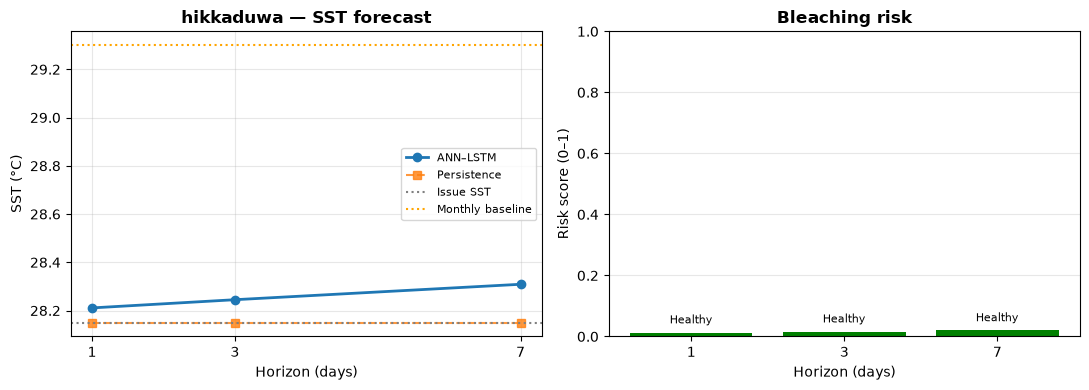

Saved lstm_deploy\forecast_hikkaduwa.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(forecast["horizon_days"], forecast["sst_pred"], "o-", label="ANN–LSTM", linewidth=2)
ax.plot(forecast["horizon_days"], forecast["sst_persist"], "s--", label="Persistence", alpha=0.8)
ax.axhline(forecast["sst_issue"].iloc[0], color="gray", linestyle=":", label="Issue SST")
ax.axhline(forecast["baseline_month_sst"].iloc[0], color="orange", linestyle=":", label="Monthly baseline")
ax.set_xticks(HORIZONS)
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("SST (°C)")
ax.set_title(f"{LOCATION} — SST forecast", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = {0: "green", 1: "gold", 2: "red"}
ax.bar(
    forecast["horizon_days"].astype(str),
    forecast["risk_score"],
    color=[colors[r] for r in forecast["risk_level"]],
)
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("Risk score (0–1)")
ax.set_ylim(0, 1)
ax.set_title("Bleaching risk", fontweight="bold")
for _, r in forecast.iterrows():
    ax.text(str(r["horizon_days"]), r["risk_score"] + 0.03, r["risk_name"], ha="center", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / f"forecast_{LOCATION}.png", dpi=130)
plt.show()
print("Saved", OUT_DIR / f"forecast_{LOCATION}.png")

## Forecast all 5 reefs (latest)

In [7]:
all_forecasts = []
for loc in LOCATIONS:
    try:
        fc = forecast_ann_lstm(loc, as_of=None)
        all_forecasts.append(fc)
        print(f"OK  {loc:12s}  issue={fc['issue_time'].iloc[0].date()}  "
              f"7d SST={fc.loc[fc.horizon_days==7, 'sst_pred'].iloc[0]:.2f}  "
              f"risk={fc.loc[fc.horizon_days==7, 'risk_name'].iloc[0]}")
    except Exception as e:
        print(f"SKIP {loc}: {e}")

board = pd.concat(all_forecasts, ignore_index=True)
board.to_csv(OUT_DIR / "all_sites_forecast.csv", index=False)
print("\nSaved", OUT_DIR / "all_sites_forecast.csv")

# Compact view: 7-day outlook
board7 = board[board["horizon_days"] == 7][[
    "location", "issue_time", "sst_issue", "sst_pred", "dhw_pred", "risk_name", "risk_score"
]].reset_index(drop=True)
board7

OK  hikkaduwa     issue=2026-03-01  7d SST=28.31  risk=Healthy
OK  kalpitiya     issue=2026-03-01  7d SST=28.62  risk=Healthy
OK  passikudha    issue=2026-03-01  7d SST=27.97  risk=Healthy
OK  south_east    issue=2026-03-01  7d SST=27.79  risk=Healthy
OK  trinco        issue=2026-03-01  7d SST=27.91  risk=Healthy

Saved lstm_deploy\all_sites_forecast.csv


,location,issue_time,sst_issue,sst_pred,dhw_pred,risk_name,risk_score
0,hikkaduwa,2026-03-01 12:00:00+00:00,28.15,28.309,0.0,Healthy,0.020
1,kalpitiya,2026-03-01 12:00:00+00:00,28.48,28.616,0.0,Healthy,0.026
2,passikudha,2026-03-01 12:00:00+00:00,27.73,27.973,0.0,Healthy,0.036
3,south_east,2026-03-01 12:00:00+00:00,27.49,27.786,0.0,Healthy,0.011
4,trinco,2026-03-01 12:00:00+00:00,27.66,27.911,0.0,Healthy,0.017


## Optional: forecast as of a past date

Useful to check what the model would have said historically.

In [8]:
PAST_LOCATION = "hikkaduwa"
PAST_AS_OF = "2025-06-01"   # must have ≥60 prior days in dataset

past_fc = forecast_ann_lstm(PAST_LOCATION, as_of=PAST_AS_OF)
print(past_fc[[
    "horizon_days", "target_date", "sst_pred", "sst_persist",
    "dhw_pred", "risk_name", "risk_score"
]].to_string(index=False))

# If truth exists in dataset, show error
g = df[df["location"] == PAST_LOCATION].sort_values("time")
issue = past_fc["issue_time"].iloc[0]
print("\nVs actuals (if available):")
for _, r in past_fc.iterrows():
    target = r["target_date"]
    hit = g[g["time"] == target]
    if len(hit):
        actual = float(hit.iloc[0]["analysed_sst"])
        err = r["sst_pred"] - actual
        print(f"  +{int(r['horizon_days'])}d  pred={r['sst_pred']:.3f}  "
              f"actual={actual:.3f}  err={err:+.3f} °C")
    else:
        print(f"  +{int(r['horizon_days'])}d  (no actual in dataset)")

 horizon_days               target_date  sst_pred  sst_persist  dhw_pred risk_name  risk_score
            1 2025-06-01 12:00:00+00:00    28.873        28.88     0.002   Healthy       0.010
            3 2025-06-03 12:00:00+00:00    28.855        28.88     0.001   Healthy       0.009
            7 2025-06-07 12:00:00+00:00    28.801        28.88     0.002   Healthy       0.006

Vs actuals (if available):
  +1d  pred=28.873  actual=28.760  err=+0.113 °C
  +3d  pred=28.855  actual=28.500  err=+0.355 °C
  +7d  pred=28.801  actual=28.780  err=+0.021 °C


## How to use in code (copy-paste)

```python
from pathlib import Path
# after running the cells above once in this kernel:
fc = forecast_ann_lstm("trinco")          # latest
fc = forecast_ann_lstm("trinco", "2025-08-15")  # as-of date
print(fc[["horizon_days", "sst_pred", "dhw_pred", "risk_name"]])
```

For a production service later, move `forecast_ann_lstm` + model load into a small `lstm_forecaster.py` module (optional follow-up).

## Summary

| Item | Value |
|------|--------|
| Model | ANN–LSTM, 60-day history |
| Inputs | Last 60 days SST + DHW |
| Outputs | SST & DHW at +1, +3, +7 days + bleaching risk |
| Baseline check | Persistence column in the table |
| Artefacts | `lstm_deploy/` |

**Digital twin split**
- **PINN** → spatial maps  
- **ANN–LSTM@60** → short-term forecasts & alerts